# QHO (Oscilador Armónico Cuántico) con DV-QCPINN

In [106]:
# ==== 0) Bootstrap de entorno y parámetros físicos ====
import os, sys, inspect, time
from pathlib import Path

def ensure_repo_root(marker='src', levels_up=6, chdir=False):
    p = Path.cwd()
    for _ in range(levels_up+1):
        if (p/marker).exists():
            if chdir:
                os.chdir(p)
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            print("Usando raíz del repo:", p)
            return p
        p = p.parent
    raise RuntimeError("No se encontró la carpeta 'src' hacia arriba. "
                       "Mueve este notebook a la raíz del repo o ajusta la ruta manualmente.")

repo_root = ensure_repo_root()

import torch, numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Parámetros físicos
L     = 5.0
T     = 0.2
hbar  = 1.0
mass  = 1.0
omega = 1.0
n_lvl = 0

# Carpeta de salida
out_dir = os.path.join(str(repo_root), "qho_outputs")
os.makedirs(out_dir, exist_ok=True)
print("Guardará resultados en:", out_dir)

Usando raíz del repo: /Users/chubbs/Documents/UN/QCPINN
Device: cpu
Guardará resultados en: /Users/chubbs/Documents/UN/QCPINN/qho_outputs


In [107]:
# ==== 1) Instanciación de DVPDESolver ====
from src.utils.logger           import Logging
from src.nn.DVPDESolver         import DVPDESolver
from src.nn.CVPDESolver         import CVPDESolver
from src.nn.ClassicalSolver2    import ClassicalSolver2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logger = Logging(out_dir)

args = {
    "num_qubits": 5,
    "num_quantum_layers": 1,
    "output_dim": 2,
    "input_dim": 2,
    "hidden_dim": 50,
    "classic_network": [2, 50, 2],
    "q_ansatz": "sim_circ_19",
    "mode": "hybrid",
    "activation": "null",
    "shots": None,
    "problem": "schrodinger",
    "solver": "Classical",
    "method": "None",
    "class": "DVNeuralNetwork",
    "encoding": "angle",
    "batch_size": 128,
    "epochs": 1000,
    "lr": 1e-3,
    "N_f": 2048, "N_b": 256, "N_0": 256,
}

if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

model.logger.print(f"The settings used:")
for key, value in args.items():
    model.logger.print(f"{key} : {value}")

print(f"Modelo {args['solver']} listo en {next(model.parameters()).device} | dtype: {next(model.parameters()).dtype}")

# Parche circuit() -> tuple
def _wrap_circuit_return_tuple(obj, attr='circuit'):
    if hasattr(obj, attr) and callable(getattr(obj, attr)):
        original = getattr(obj, attr)
        def wrapped(sample):
            out = original(sample)
            if isinstance(out, torch.Tensor):
                return (out,)
            elif isinstance(out, (list, tuple)):
                return tuple(out)
            else:
                return (torch.as_tensor(out, device=sample.device, dtype=sample.dtype),)
        setattr(obj, attr, wrapped)
        print(f"Patched {obj.__class__.__name__}.{attr} -> returns tuple")
        return True
    return False

patched = _wrap_circuit_return_tuple(model, 'circuit')
if not patched and hasattr(model, 'modules'):
    for m in model.modules():
        if _wrap_circuit_return_tuple(m, 'circuit'):
            patched = True
            break
print("circuit patched:", patched)

INFO:src.utils.logger:checkpoint path: self.log_path='/Users/chubbs/Documents/UN/QCPINN/qho_outputs/2025-08-18_16-38-41-683904'
INFO:src.utils.logger:Using Classical Solver
INFO:src.utils.logger:The settings used:
INFO:src.utils.logger:num_qubits : 5


INFO:src.utils.logger:num_quantum_layers : 1
INFO:src.utils.logger:output_dim : 2
INFO:src.utils.logger:input_dim : 2
INFO:src.utils.logger:hidden_dim : 50
INFO:src.utils.logger:classic_network : [2, 50, 2]
INFO:src.utils.logger:q_ansatz : sim_circ_19
INFO:src.utils.logger:mode : hybrid
INFO:src.utils.logger:activation : null
INFO:src.utils.logger:shots : None
INFO:src.utils.logger:problem : schrodinger
INFO:src.utils.logger:solver : Classical
INFO:src.utils.logger:method : None
INFO:src.utils.logger:class : DVNeuralNetwork
INFO:src.utils.logger:encoding : angle
INFO:src.utils.logger:batch_size : 128
INFO:src.utils.logger:epochs : 1000
INFO:src.utils.logger:lr : 0.001
INFO:src.utils.logger:N_f : 2048
INFO:src.utils.logger:N_b : 256
INFO:src.utils.logger:N_0 : 256


Modelo Classical listo en cpu | dtype: torch.float32
circuit patched: False


In [108]:
# ==== 2) Herramientas analíticas del HO ====
import math
import torch

def hermite_physicists(n, z):
    if n == 0: return torch.ones_like(z)
    if n == 1: return 2.0*z
    Hnm2 = torch.ones_like(z); Hnm1 = 2.0*z
    for k in range(1, n):
        Hn = 2.0*z*Hnm1 - 2.0*k*Hnm2
        Hnm2, Hnm1 = Hnm1, Hn
    return Hnm1

def exact_eigenstate_ho(n, t, x, mass=1.0, omega=1.0, hbar=1.0):
    xi   = math.sqrt(mass*omega/hbar) * x
    fact = math.factorial(n)
    norm = (mass*omega/(math.pi*hbar))**0.25 * (1.0/math.sqrt((2.0**n)*fact))
    phi_x = norm * hermite_physicists(n, xi) * torch.exp(-0.5*(xi**2))
    E_n   = hbar*omega*(n + 0.5)
    phase = -(E_n/hbar) * t
    psi_r = phi_x * torch.cos(phase)
    psi_i = phi_x * torch.sin(phase)
    return psi_r, psi_i

In [109]:
# ==== 3) Operador local de Schrödinger (HO) ====
import torch.nn as nn
import torch.optim as optim

mse = nn.MSELoss()

def schrodinger_operator_local(model, t, x, mass=1.0, hbar=1.0, omega=1.0):
    t = t.requires_grad_(True)
    x = x.requires_grad_(True)
    psi   = model(torch.cat([t, x], dim=1))
    psi_r = psi[:, 0:1]; psi_i = psi[:, 1:2]

    psi_t_r = torch.autograd.grad(psi_r, t, torch.ones_like(psi_r), create_graph=True)[0]
    psi_t_i = torch.autograd.grad(psi_i, t, torch.ones_like(psi_i), create_graph=True)[0]

    psi_x_r  = torch.autograd.grad(psi_r, x, torch.ones_like(psi_r), create_graph=True)[0]
    psi_x_i  = torch.autograd.grad(psi_i, x, torch.ones_like(psi_i), create_graph=True)[0]
    psi_xx_r = torch.autograd.grad(psi_x_r, x, torch.ones_like(psi_x_r), create_graph=True)[0]
    psi_xx_i = torch.autograd.grad(psi_x_i, x, torch.ones_like(psi_x_i), create_graph=True)[0]

    V    = 0.5 * mass * (omega**2) * (x**2)
    coef = (hbar**2) / (2.0 * mass)
    residual_r = -hbar * psi_t_i + coef * psi_xx_r - V * psi_r
    residual_i =  hbar * psi_t_r + coef * psi_xx_i - V * psi_i
    return residual_r, residual_i, psi_r, psi_i

In [110]:
# ==== 4) Fine-tuning rápido con micro-batches ====
def train_qho_dv_fast(
    model, *,
    epochs=100,
    Nf=2048, Nb=256, N0=256,
    mb_f=128, mb_b=64, mb_0=64,
    w_pde=1.0, w_bc=2.0, w_ic=2.0,
    L=5.0, T=0.2, mass=1.0, omega=1.0, hbar=1.0, n_lvl=0,
    lr=1e-3, PRINT_EVERY = 10
):
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)

    def rand_interior(mb):
        t = torch.rand(mb,1, device=device)*T
        x = (torch.rand(mb,1, device=device)-0.5)*2*L
        return t, x

    def rand_borde(mb):
        t = torch.rand(mb,1, device=device)*T
        sides = torch.randint(0,2,(mb,1), device=device)
        x = torch.where(sides==0, torch.full_like(t, -L), torch.full_like(t, +L))
        return t, x

    def rand_inicial(mb):
        t = torch.zeros(mb,1, device=device)
        x = (torch.rand(mb,1, device=device)-0.5)*2*L
        return t, x

    steps_f = (Nf - 1)
    steps_b = (Nb - 1)
    steps_0 = (N0 - 1)

    t_f, x_f = rand_interior(Nf)
    t_b, x_b = rand_borde(Nb)
    t_0, x_0 = rand_inicial(N0)

    tstart = time.time()
    
    for ep in range(1, epochs+1):
        opt.zero_grad()
        loss_pde_total = 0.0
        loss_bc_total  = 0.0
        loss_ic_total  = 0.0

        """
        # PDE
        for _ in range(steps_f):
            t_f, x_f = rand_interior(Nf)
            rR, rI, _, _ = schrodinger_operator_local(model, t_f, x_f, mass=mass, hbar=hbar, omega=omega)
            loss_pde_mb = torch.mean(rR**2) + torch.mean(rI**2)
            loss_pde_mb.backward()
            loss_pde_total += loss_pde_mb.item()

        # BC
        for _ in range(steps_b):
            t_b, x_b = rand_borde(Nb)
            psi_b = model(torch.cat([t_b, x_b], dim=1))
            loss_bc_mb = mse(psi_b[:,0:1], torch.zeros_like(psi_b[:,0:1])) + \
                         mse(psi_b[:,1:2], torch.zeros_like(psi_b[:,1:2]))
            loss_bc_mb.backward()
            loss_bc_total += loss_bc_mb.item()

        # IC
        for _ in range(steps_0):
            t_0, x_0 = rand_inicial(N0)
            psi0_r, psi0_i = exact_eigenstate_ho(n_lvl, t_0, x_0, mass=mass, omega=omega, hbar=hbar)
            psi0 = model(torch.cat([t_0, x_0], dim=1))
            loss_ic_mb = mse(psi0[:,0:1], psi0_r) + mse(psi0[:,1:2], psi0_i)
            loss_ic_mb.backward()
            loss_ic_total += loss_ic_mb.item()
        """

        # Minibatch reductions
        rR, rI, _, _ = schrodinger_operator_local(model, t_f, x_f, mass=mass, hbar=hbar, omega=omega)
        loss_pde_total = torch.mean(rR**2) + torch.mean(rI**2)

        psi_b = model(torch.cat([t_b, x_b], dim=1))
        loss_bc_total = mse(psi_b[:,0:1], torch.zeros_like(psi_b[:,0:1])) + \
                         mse(psi_b[:,1:2], torch.zeros_like(psi_b[:,1:2]))

        psi0_r, psi0_i = exact_eigenstate_ho(n_lvl, t_0, x_0, mass=mass, omega=omega, hbar=hbar)
        psi0 = model(torch.cat([t_0, x_0], dim=1))

        loss_ic_total = mse(psi0[:,0:1], psi0_r) + mse(psi0[:,1:2], psi0_i)

        tot = w_pde * loss_pde_total + w_bc * loss_bc_total + w_ic * loss_ic_total

        tot.backward()
        opt.step()
        
        if ep % PRINT_EVERY == 0 or ep == 1:
            elapsed = time.time() - tstart
            print(f"ep {ep:3d} | loss {tot:.3e} | pde {loss_pde_total:.3e} | bc {loss_bc_total:.3e} | ic {loss_ic_total:.3e} : elapsed {elapsed:.1e} s")

    return model

model = model.to(device)
model = train_qho_dv_fast(
    model,
    epochs=1000,
    Nf=10, Nb=10, N0=10,
    w_pde=1.0, w_bc=1.0, w_ic=3.0,
    L=L, T=T, mass=mass, omega=omega, hbar=hbar, n_lvl=n_lvl,
    lr=args.get("lr", 1e-3), PRINT_EVERY= 100,
)

ep   1 | loss 1.303e+00 | pde 9.683e-01 | bc 4.527e-02 | ic 9.655e-02 : elapsed 7.5e-02 s
ep 100 | loss 9.115e-02 | pde 2.672e-03 | bc 2.321e-05 | ic 2.948e-02 : elapsed 1.9e+01 s
ep 200 | loss 2.672e-02 | pde 4.612e-03 | bc 1.011e-04 | ic 7.337e-03 : elapsed 2.7e+01 s
ep 300 | loss 5.651e-03 | pde 2.075e-03 | bc 3.054e-05 | ic 1.182e-03 : elapsed 3.1e+01 s
ep 400 | loss 2.345e-03 | pde 9.596e-04 | bc 1.831e-05 | ic 4.556e-04 : elapsed 3.5e+01 s
ep 500 | loss 1.266e-03 | pde 5.853e-04 | bc 1.638e-05 | ic 2.214e-04 : elapsed 3.8e+01 s
ep 600 | loss 7.009e-04 | pde 3.640e-04 | bc 1.497e-05 | ic 1.073e-04 : elapsed 4.0e+01 s
ep 700 | loss 4.985e-04 | pde 2.993e-04 | bc 2.186e-05 | ic 5.911e-05 : elapsed 4.3e+01 s
ep 800 | loss 2.989e-04 | pde 1.963e-04 | bc 1.561e-05 | ic 2.900e-05 : elapsed 4.6e+01 s
ep 900 | loss 2.203e-04 | pde 1.588e-04 | bc 1.760e-05 | ic 1.463e-05 : elapsed 4.9e+01 s
ep 1000 | loss 2.048e-04 | pde 1.548e-04 | bc 1.845e-05 | ic 1.050e-05 : elapsed 5.4e+01 s



=== t=0.0000 ===
Error relativo L2: 8.408e-02


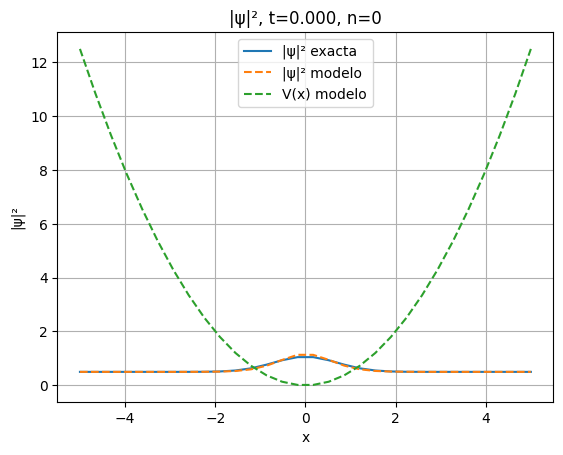

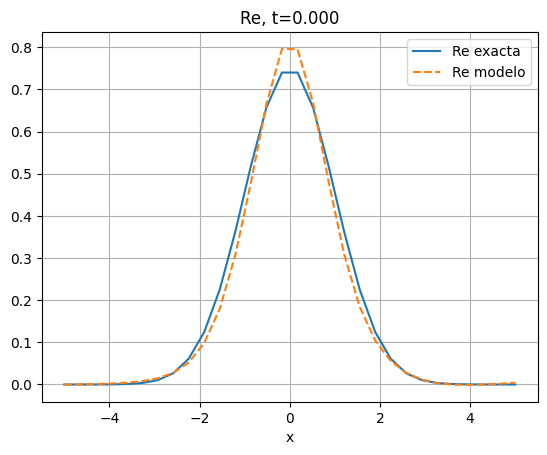

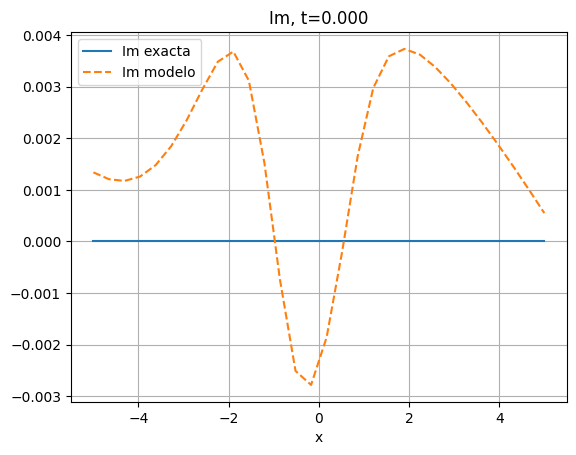


=== t=0.1000 ===
Error relativo L2: 8.427e-02


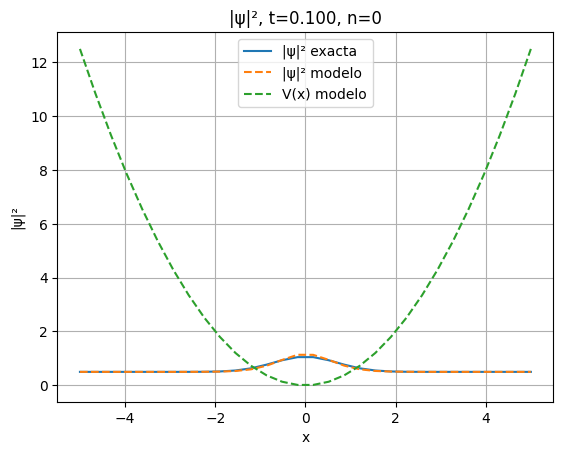

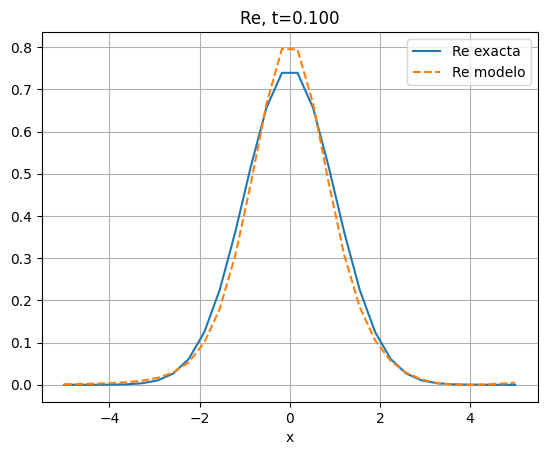

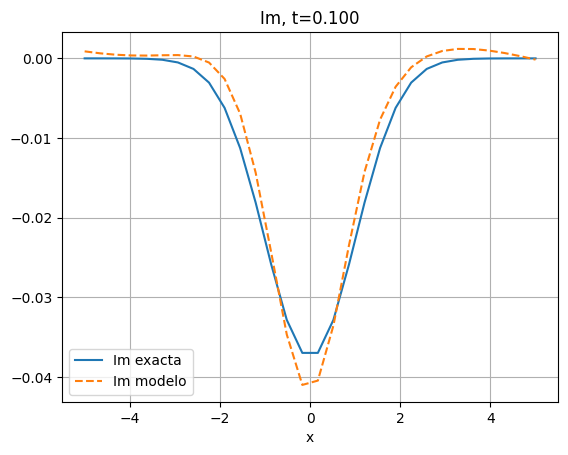


=== t=0.2000 ===
Error relativo L2: 8.382e-02


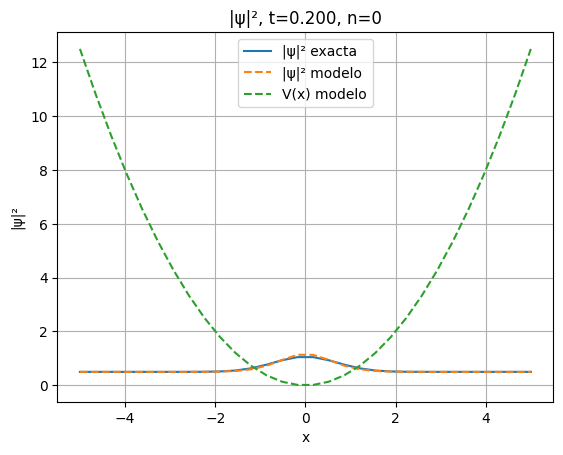

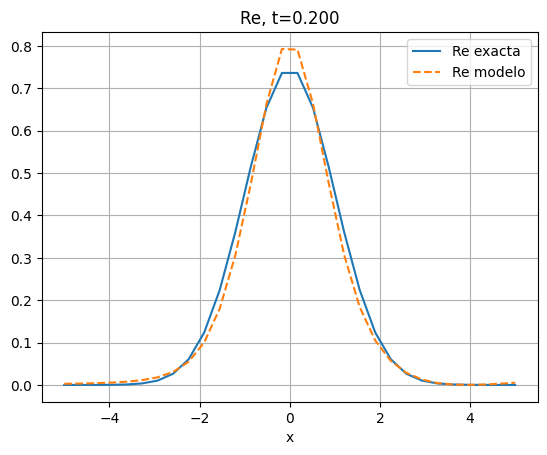

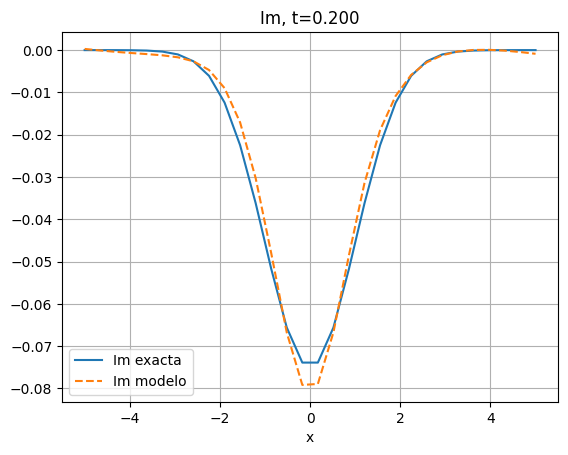

Guardado CSV: /Users/chubbs/Documents/UN/QCPINN/qho_outputs/errores_relativos.csv


In [111]:
# ==== 5) Comparación exacta vs. modelo ====
@torch.no_grad()
def predict_dv(model, t_eval, x_eval):
    inp = torch.cat((t_eval, x_eval), dim=1)
    out = model(inp)
    psi_r = out[:, 0:1].squeeze(1)
    psi_i = out[:, 1:2].squeeze(1)
    return psi_r, psi_i

def complex_from_ri(psi_r, psi_i):
    return psi_r + 1j*psi_i

def normalize(psi, x):
    dx = (x[1]-x[0]).item()
    norm = torch.sqrt(torch.sum(torch.abs(psi)**2)*dx)
    return psi / (norm + 1e-12)

def best_phase_align(psi_ref, psi_pred, x):
    dx = (x[1]-x[0]).item()
    inner = torch.sum(torch.conj(psi_ref)*psi_pred)*dx
    theta = -torch.angle(inner)
    return torch.exp(1j*theta)

def rel_L2_error(psi_ref, psi_est, x):
    dx = (x[1]-x[0]).item()
    num = torch.sqrt(torch.sum(torch.abs(psi_ref-psi_est)**2)*dx)
    den = torch.sqrt(torch.sum(torch.abs(psi_ref)**2)*dx) + 1e-12
    return (num/den).item()

import os
N_plot = 30
x_eval = torch.linspace(-L, L, N_plot, device=device).unsqueeze(1)
t_list = [0.0, T/2, T]

errors = []
for tval in t_list:
    print(f"\n=== t={tval:.4f} ===")
    t_eval = torch.full_like(x_eval, fill_value=tval)

    psi_r_pred, psi_i_pred = predict_dv(model, t_eval, x_eval)
    psi_pred = complex_from_ri(psi_r_pred, psi_i_pred)

    psi_r_ex, psi_i_ex = exact_eigenstate_ho(n_lvl, t_eval, x_eval, mass=mass, omega=omega, hbar=hbar)
    psi_exact = complex_from_ri(psi_r_ex.squeeze(1), psi_i_ex.squeeze(1))

    psi_pred_n  = normalize(psi_pred, x_eval.squeeze(1))
    psi_exact_n = normalize(psi_exact, x_eval.squeeze(1))
    phase = best_phase_align(psi_exact_n, psi_pred_n, x_eval.squeeze(1))
    psi_pred_aligned = phase * psi_pred_n

    e_rel = rel_L2_error(psi_exact_n, psi_pred_aligned, x_eval.squeeze(1))
    errors.append((tval, e_rel))
    print(f"Error relativo L2: {e_rel:.3e}")

    xx = x_eval.squeeze(1).detach().cpu().numpy()
    mod2_pred = torch.abs(psi_pred_aligned)**2
    mod2_ex   = torch.abs(psi_exact_n)**2

    E_n = hbar*omega*(n_lvl + 0.5)

    plt.figure()
    plt.plot(xx, E_n + mod2_ex.cpu().numpy(), label="|ψ|² exacta")
    plt.plot(xx, E_n + mod2_pred.cpu().numpy(), "--", label="|ψ|² modelo")
    plt.plot(xx, 0.5*mass*(omega**2)*(xx**2), "--", label="V(x) modelo")
    plt.xlabel("x"); plt.ylabel("|ψ|²"); plt.legend(); plt.grid(True)
    plt.title(f"|ψ|², t={tval:.3f}, n={n_lvl}")
    plt.savefig(os.path.join(out_dir, f"mod2_t{tval:.3f}.png"), dpi=140, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(xx, psi_exact_n.real.cpu().numpy(), label="Re exacta")
    plt.plot(xx, psi_pred_aligned.real.cpu().numpy(), "--", label="Re modelo")
    plt.xlabel("x"); plt.legend(); plt.grid(True)
    plt.title(f"Re, t={tval:.3f}")
    plt.savefig(os.path.join(out_dir, f"real_t{tval:.3f}.png"), dpi=140, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(xx, psi_exact_n.imag.cpu().numpy(), label="Im exacta")
    plt.plot(xx, psi_pred_aligned.imag.cpu().numpy(), "--", label="Im modelo")
    plt.xlabel("x"); plt.legend(); plt.grid(True)
    plt.title(f"Im, t={tval:.3f}")
    plt.savefig(os.path.join(out_dir, f"imag_t{tval:.3f}.png"), dpi=140, bbox_inches="tight")
    plt.show()

# CSV de errores
import csv
csv_path = os.path.join(out_dir, "errores_relativos.csv")
with open(csv_path, "w", newline="") as f:
    wr = csv.writer(f); wr.writerow(["t", "rel_L2_error"]); wr.writerows(errors)
print("Guardado CSV:", csv_path)

In [112]:
# ==== 6) (Opcional) Estimación de energía <H> ====
@torch.no_grad()
def kinetic_energy(psi, x, mass=1.0, hbar=1.0):
    dx = (x[1]-x[0]).item()
    psi_np = psi.detach().cpu().numpy()
    d2 = (psi_np[:-2] - 2*psi_np[1:-1] + psi_np[2:]) / (dx*dx)
    d2 = torch.tensor(d2, device=psi.device)
    psi_mid = psi[1:-1]
    return (-(hbar**2)/(2*mass)) * torch.sum(torch.conj(psi_mid)*d2).real * dx

@torch.no_grad()
def potential_energy(psi, x, mass=1.0, omega=1.0):
    V = 0.5*mass*(omega**2)*(x**2)
    dx = (x[1]-x[0]).item()
    return torch.sum(torch.conj(psi)*V*psi).real * dx

t_eval = torch.full_like(x_eval, fill_value=T)
psi_r_pred, psi_i_pred = predict_dv(model, t_eval, x_eval)
psi_pred = psi_r_pred + 1j*psi_i_pred
psi_pred_n = normalize(psi_pred, x_eval.squeeze(1))

KE = kinetic_energy(psi_pred_n, x_eval.squeeze(1), mass=mass, hbar=hbar)
PE = potential_energy(psi_pred_n, x_eval.squeeze(1), mass=mass, omega=omega)
E_est = (KE+PE).item()
E_exact = (hbar*omega*(n_lvl+0.5))
print(f"<H> ≈ {E_est:.6f}  vs  E_exact = {E_exact:.6f}")

<H> ≈ 0.512241  vs  E_exact = 0.500000
